In [1]:
# Step 1: Import
import pandas as pd
import re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Step 2: Load Data (ONLY train.csv)
df = pd.read_csv("AG_news(train).csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [3]:
# Step 3: Combine text (important)
df["text"] = df["Title"] + " " + df["Description"]

In [4]:
# Step 4: Preprocessing
stop_words = set(stopwords.words('english'))
lemma = WordNetLemmatizer()

def clean(text):
    text = re.sub(r'[^a-z\s]', '', text.lower())
    words = word_tokenize(text)
    return " ".join([lemma.lemmatize(w) for w in words if w not in stop_words])

df["clean"] = df["text"].apply(clean)

In [5]:
# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["Class Index"], test_size=0.2, random_state=42
)

In [6]:
# Step 6: TF-IDF
vec = TfidfVectorizer(max_features=5000)
X_train = vec.fit_transform(X_train)
X_test = vec.transform(X_test)

In [7]:
#Step 8: Train Models

In [8]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [9]:
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8947083333333333
              precision    recall  f1-score   support

           1       0.90      0.88      0.89      5956
           2       0.94      0.97      0.96      6058
           3       0.86      0.86      0.86      5911
           4       0.88      0.86      0.87      6075

    accuracy                           0.89     24000
   macro avg       0.89      0.89      0.89     24000
weighted avg       0.89      0.89      0.89     24000



In [10]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [11]:
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.908
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.96      6058
           3       0.87      0.88      0.87      5911
           4       0.89      0.88      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [12]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.88375
              precision    recall  f1-score   support

           1       0.90      0.89      0.89      5956
           2       0.91      0.96      0.94      6058
           3       0.85      0.85      0.85      5911
           4       0.87      0.84      0.85      6075

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



<BarContainer object of 3 artists>

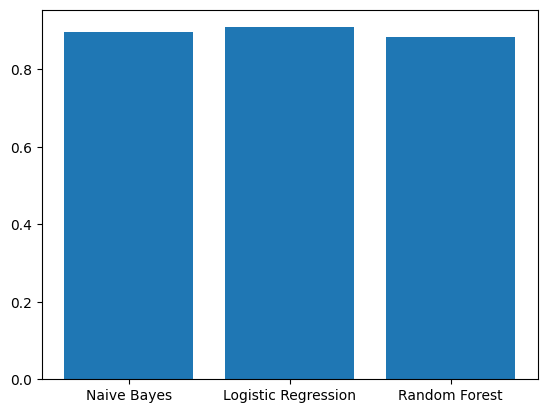

In [14]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression", "Random Forest"]
acc = [nb_acc, lr_acc, rf_acc]

plt.bar(models, acc)

In [15]:
# Step 11: Sample Prediction (Categorization)
labels = {1:"World", 2:"Sports", 3:"Business", 4:"Sci/Tech"}

sample = "Stock market rises due to tech growth"
sample_clean = clean(sample)

pred = lr.predict(vec.transform([sample_clean]))[0]
print("Predicted Category:", labels[pred])

Predicted Category: Business
